# 03 · Modeling

Compare **Logistic Regression**, **Random Forest** and **XGBoost** on the same
engineered features, with 5-fold stratified cross-validation and threshold
tuning for the imbalanced churn class.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from churn import config, data, features, model

df = features.engineer(data.load_clean())
X_train, X_test, y_train, y_test = model.make_split(df)
models = model.build_models()
print("train:", X_train.shape, "| test:", X_test.shape)

train: (5634, 23) | test: (1409, 23)


## Cross-validation (5-fold, stratified)
All three models land within noise of each other (~0.85 ROC-AUC).

In [2]:
cv = model.cross_validate_models(models, X_train, y_train)
cv[["roc_auc_mean", "f1_mean", "precision_mean", "recall_mean"]].round(4)

,roc_auc_mean,f1_mean,precision_mean,recall_mean
model,,,,
Logistic Regression,0.8457,0.6282,0.5190,0.7960
Random Forest,0.8483,0.6318,0.5261,0.7913
XGBoost,0.8482,0.6318,0.5268,0.7893


## Held-out test set
Fit on train, scored **once** on the untouched test split.

In [3]:
rows = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows[name] = model.evaluate(y_test, proba, threshold=0.5)
pd.DataFrame(rows).T[["roc_auc", "precision", "recall", "f1"]].round(4)

,roc_auc,precision,recall,f1
Logistic Regression,0.8424,0.4983,0.7914,0.6116
Random Forest,0.8448,0.5275,0.7941,0.6339
XGBoost,0.8458,0.5202,0.7914,0.6278


## Threshold tuning

The default 0.5 cut-off is rarely optimal on an imbalanced target. We tune the
threshold on **out-of-fold training predictions** (never the test set) to
maximise F1 on the churn class.

tuned threshold = 0.569 | F1=0.638 precision=0.567 recall=0.730


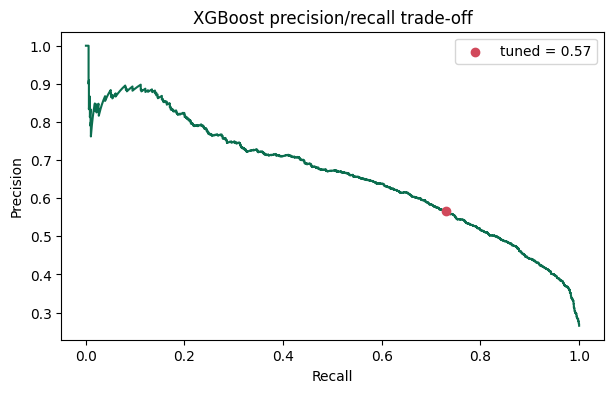

In [4]:
xgb = models["XGBoost"]
oof = model.oof_proba(xgb, X_train, y_train)
tuned = model.tune_threshold(y_train.to_numpy(), oof)
print(f"tuned threshold = {tuned.threshold:.3f} | F1={tuned.f1:.3f} "
      f"precision={tuned.precision:.3f} recall={tuned.recall:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tuned.curve["recall"], tuned.curve["precision"], color="#0b6e4f")
ax.scatter([tuned.recall], [tuned.precision], color="#d1495b", zorder=5,
           label=f"tuned = {tuned.threshold:.2f}")
ax.set(xlabel="Recall", ylabel="Precision", title="XGBoost precision/recall trade-off")
ax.legend();

## Confusion matrix at the tuned threshold

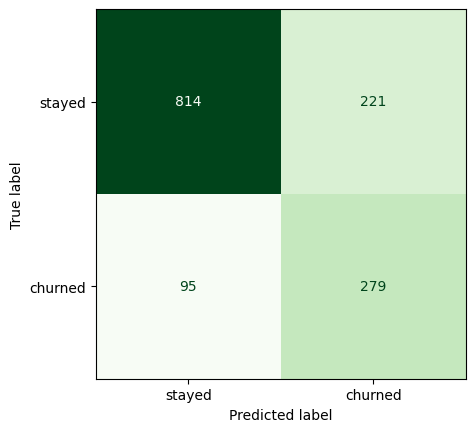

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= tuned.threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["stayed", "churned"], cmap="Greens", colorbar=False
);

## Conclusion

The three models are statistically tied at **~0.85 ROC-AUC** - a realistic
ceiling for this dataset on a clean held-out split. **XGBoost** is taken forward
as the production model for its held-out AUC, low-variance CV, and native SHAP
tree-explanations (notebook 04).